## NBA Historical Performance Analysis
-- Database: nba.sqlite (Kaggle - wyattowalsh/basketball)

# 🏀 NBA Historical Performance Analysis

This notebook analyzes NBA history using SQL — franchise success, scoring
trends across eras, win streaks, home-court advantage, and draft outcomes —
querying a relational SQLite database (64,000+ games, 1946–2023).

A key methodological finding of this project: **the "greatest NBA
franchise" ranking depends entirely on how you define success** —
different game types (regular season vs. playoffs) and different entity
levels (team-era vs. consolidated franchise) produce different answers.
This notebook makes those choices explicit rather than picking one
silently.

**Questions this analysis answers:**
1. Which franchises have the most all-time wins (regular season, playoffs, combined)?
2. How has scoring per game changed across NBA eras?
3. Which franchises score the most points per game on average?
4. What was the longest win streak for any team-era in NBA history?
5. For a standout season, what's the game-by-game scoring trend?
6. Which franchises have the strongest home-court advantage?
7. Does draft position predict whether a player ever plays in the NBA?

## 1. Connect to the Database

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('/Users/hazeezatadebayo/Downloads/archive (2)/nba.sqlite')

tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(tables)

                   name
0                  game
1          game_summary
2           other_stats
3             officials
4      inactive_players
5             game_info
6            line_score
7          play_by_play
8                player
9                  team
10   common_player_info
11         team_details
12         team_history
13  draft_combine_stats
14        draft_history
15     team_info_common


## 2. Franchise Mapping (dim_franchise)

`game` stores team_id_home/team_id_away, which stay constant across a
franchise's relocations and name changes (verified: Minneapolis Lakers
and Los Angeles Lakers both map to team_id 1610612747). Building one
reusable franchise-mapping query here avoids repeating the same join
logic across Q1, Q3, and Q6.

In [24]:
dim_franchise = """
SELECT id AS team_id, full_name AS franchise_name
FROM team
"""
df_franchise = pd.read_sql(dim_franchise, conn)
print(df_franchise.head())
print(f"\nTotal franchises: {len(df_franchise)}")

      team_id        franchise_name
0  1610612737         Atlanta Hawks
1  1610612738        Boston Celtics
2  1610612739   Cleveland Cavaliers
3  1610612740  New Orleans Pelicans
4  1610612741         Chicago Bulls

Total franchises: 30


## Q1 — Which franchises have the most all-time wins under different definitions of success?

Methodology: `team_id_home`/`team_id_away` combined via `UNION ALL`
(not team_name — this consolidates relocated/renamed franchises, e.g.
Minneapolis Lakers + LA Lakers). Preseason and All-Star games excluded.
Regular season and playoffs calculated separately, then combined.

In [27]:
q1_regular = """
SELECT t.full_name AS franchise_name, SUM(win) AS regular_season_wins
FROM (
    SELECT team_id_home AS team_id, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
    UNION ALL
    SELECT team_id_away AS team_id, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
) combined
JOIN team t ON combined.team_id = t.id
GROUP BY t.full_name
ORDER BY regular_season_wins DESC;
"""

q1_playoffs = """
SELECT t.full_name AS franchise_name, SUM(win) AS playoff_wins
FROM (
    SELECT team_id_home AS team_id, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Playoffs'
    UNION ALL
    SELECT team_id_away AS team_id, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Playoffs'
) combined
JOIN team t ON combined.team_id = t.id
GROUP BY t.full_name
ORDER BY playoff_wins DESC;
"""

df_q1_regular = pd.read_sql(q1_regular, conn)
df_q1_playoffs = pd.read_sql(q1_playoffs, conn)

df_q1_combined = df_q1_regular.merge(df_q1_playoffs, on='franchise_name', how='left')
df_q1_combined['playoff_wins'] = df_q1_combined['playoff_wins'].fillna(0)
df_q1_combined['combined_wins'] = df_q1_combined['regular_season_wins'] + df_q1_combined['playoff_wins']
df_q1_combined = df_q1_combined.sort_values('combined_wins', ascending=False).head(10)
df_q1_combined = df_q1_combined.reset_index(drop=True)
print(df_q1_combined)

          franchise_name  regular_season_wins  playoff_wins  combined_wins
0     Los Angeles Lakers                 3193           402           3595
1         Boston Celtics                 3210           356           3566
2     Philadelphia 76ers                 2731           224           2955
3        New York Knicks                 2654           160           2814
4  Golden State Warriors                 2591           207           2798
5          Atlanta Hawks                 2633           138           2771
6        Detroit Pistons                 2559           168           2727
7       Sacramento Kings                 2455            67           2522
8      San Antonio Spurs                 2181           204           2385
9  Oklahoma City Thunder                 2232           145           2377


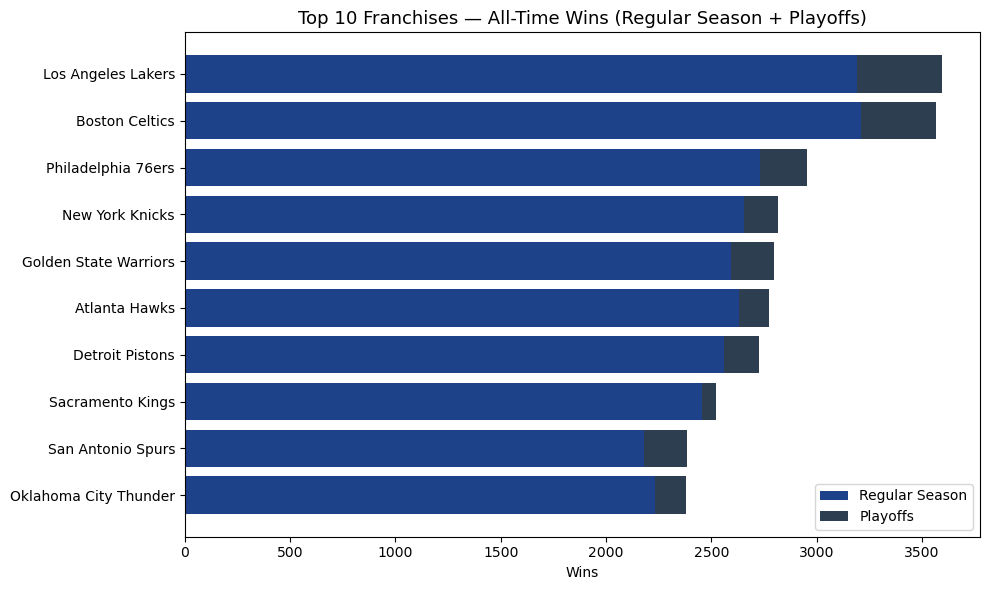

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
top10 = df_q1_combined.sort_values('combined_wins')
ax.barh(top10['franchise_name'], top10['regular_season_wins'], color='#1D428A', label='Regular Season')
ax.barh(top10['franchise_name'], top10['playoff_wins'], left=top10['regular_season_wins'], color='#2C3E50', label='Playoffs')
ax.set_title('Top 10 Franchises — All-Time Wins (Regular Season + Playoffs)', fontsize=13)
ax.set_xlabel('Wins')
ax.legend()
plt.tight_layout()
plt.savefig('q1_franchise_wins.png', dpi=150)
plt.show()

### Q1 Findings

| Franchise | Regular Season | Playoffs | Combined |
|---|---|---|---|
| Boston Celtics | 3,210 | 356 | 3,566 |
| Los Angeles Lakers | 3,193 | 402 | 3,595 |

**Internal validation:** regular season + playoff wins sum exactly to the
combined total for both franchises (Lakers: 3,193 + 402 = 3,595; Celtics:
3,210 + 356 = 3,566) — confirming the query logic is correct.

**Key finding:** the "greatest NBA franchise" ranking depends on the
definition of success used. The Celtics lead in regular-season wins
alone; the Lakers overtake them once playoff wins are included.

**Limitation — external validation:** this dataset's franchise win totals
were internally validated by reconciling regular-season and playoff
components, but do not precisely match some externally reported figures
(e.g., Wikipedia's Lakers all-time win count of 3,550, as of Aug 2024).
Franchise consolidation via `team_id` was confirmed correctly implemented
(verified against the Minneapolis/LA Lakers example), so it does not by
itself explain the gap. The discrepancy may reflect differences in
historical data coverage, source methodology, or counting definitions
across sources, and is not further resolved here — noted as an open
limitation rather than an explained one.

## Q2 — How has scoring per game changed across NBA eras?

**Finding:** scoring peaked in the 1960s (~228 combined pts/game),
declined through a low point in the 2000s (~194), and has risen again
since 2010 (~205–224) — consistent with the NBA's well-documented
3-point-era shift.

*Note: 1940s figure (1,187 games) is a small sample relative to other
decades and treated as less reliable. The 2020s (4,626 games) reflects an
incomplete decade, not a full one.*

In [29]:
q2 = """
SELECT 
    (CAST(STRFTIME('%Y', game_date) AS INTEGER) / 10) * 10 AS decade,
    AVG(pts_home + pts_away) AS avg_total_points_per_game,
    COUNT(*) AS game_count
FROM game
WHERE pts_home IS NOT NULL AND pts_away IS NOT NULL
GROUP BY decade
ORDER BY decade;
"""
df_q2 = pd.read_sql(q2, conn)
print(df_q2)

   decade  avg_total_points_per_game  game_count
0    1940                 150.044650        1187
1    1950                 183.495378        3462
2    1960                 227.877879        3169
3    1970                 216.006175        5830
4    1980                 218.183789       10055
5    1990                 201.762728       11569
6    2000                 193.901390       13305
7    2010                 205.457703       12495
8    2020                 224.449633        4626


In [41]:
# Metric 1: Regular Season Wins
q1_regular = """
SELECT team_name, SUM(win) AS regular_season_wins
FROM (
    SELECT team_name_home AS team_name, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
    UNION ALL
    SELECT team_name_away AS team_name, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
) combined
GROUP BY team_name
ORDER BY regular_season_wins DESC
LIMIT 10;
"""

# Metric 2: Playoff Wins
q1_playoffs = """
SELECT team_name, SUM(win) AS playoff_wins
FROM (
    SELECT team_name_home AS team_name, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Playoffs'
    UNION ALL
    SELECT team_name_away AS team_name, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Playoffs'
) combined
GROUP BY team_name
ORDER BY playoff_wins DESC
LIMIT 10;
"""

# Metric 3: Total Wins (Regular Season + Playoffs combined)
q1_total = """
SELECT team_name, SUM(win) AS total_wins
FROM (
    SELECT team_name_home AS team_name, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type IN ('Regular Season', 'Playoffs')
    UNION ALL
    SELECT team_name_away AS team_name, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type IN ('Regular Season', 'Playoffs')
) combined
GROUP BY team_name
ORDER BY total_wins DESC
LIMIT 10;
"""

print("REGULAR SEASON:")
print(pd.read_sql(q1_regular, conn))
print("\nPLAYOFFS:")
print(pd.read_sql(q1_playoffs, conn))
print("\nTOTAL:")
print(pd.read_sql(q1_total, conn))

REGULAR SEASON:
                team_name  regular_season_wins
0          Boston Celtics                 3210
1      Los Angeles Lakers                 2734
2         New York Knicks                 2654
3         Detroit Pistons                 2245
4      Philadelphia 76ers                 2233
5            Phoenix Suns                 2231
6       San Antonio Spurs                 2181
7         Milwaukee Bucks                 2168
8           Chicago Bulls                 2147
9  Portland Trail Blazers                 2123

PLAYOFFS:
               team_name  playoff_wins
0         Boston Celtics           356
1     Los Angeles Lakers           343
2      San Antonio Spurs           204
3     Philadelphia 76ers           184
4          Chicago Bulls           164
5        New York Knicks           160
6  Golden State Warriors           156
7        Detroit Pistons           151
8        Milwaukee Bucks           147
9           Phoenix Suns           139

TOTAL:
                tea

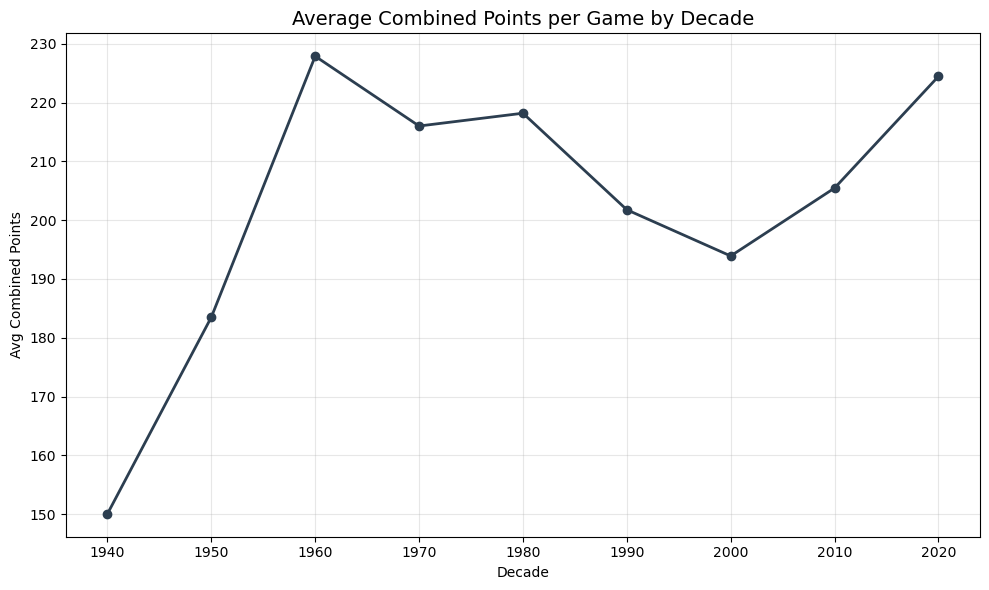

In [42]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(df_q2['decade'], df_q2['avg_total_points_per_game'], marker='o', linewidth=2, color='#2C3E50')
ax.set_title('Average Combined Points per Game by Decade', fontsize=14)
ax.set_xlabel('Decade')
ax.set_ylabel('Avg Combined Points')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('q2_scoring_by_decade.png', dpi=150)
plt.show()

## Q3 — Which franchises have the highest scoring averages across their history?

Updated to `team_id` consolidation (same reasoning as Q1) — historical
team names previously split franchises (e.g. Cincinnati Royals vs.
Sacramento Kings appeared separately). `HAVING` requires 500+ games to
avoid short-history franchises skewing the ranking. Revised from
player-level to team-level: `game`/`line_score` have no individual
player box scores outside `play_by_play` (excluded, out of scope).

In [31]:
q3 = """
SELECT t.full_name AS franchise_name, AVG(pts) AS avg_points, COUNT(*) AS games_played
FROM (
    SELECT team_id_home AS team_id, pts_home AS pts
    FROM game WHERE season_type IN ('Regular Season', 'Playoffs')
    UNION ALL
    SELECT team_id_away AS team_id, pts_away AS pts
    FROM game WHERE season_type IN ('Regular Season', 'Playoffs')
) combined
JOIN team t ON combined.team_id = t.id
WHERE pts IS NOT NULL
GROUP BY t.full_name
HAVING games_played >= 500
ORDER BY avg_points DESC
LIMIT 10;
"""
df_q3 = pd.read_sql(q3, conn)
print(df_q3)

           franchise_name  avg_points  games_played
0            Phoenix Suns  107.822632          4392
1          Denver Nuggets  107.600365          3836
2      Los Angeles Lakers  105.658371          6027
3   Oklahoma City Thunder  105.320419          4491
4         Houston Rockets  104.998884          4481
5  Portland Trail Blazers  104.888518          4198
6   Golden State Warriors  104.822245          5817
7         Milwaukee Bucks  104.771707          4411
8       San Antonio Spurs  104.664826          3983
9          Boston Celtics  104.375860          6106


## Q4 — What was the longest win streak for any team-era in NBA history?

**Kept at team_name level, not consolidated to franchise.** Unlike
franchise-level metrics, a win streak represents a specific roster,
coaching staff, and competitive era, not franchise longevity — the
Lakers' 33-game streak belongs to the 1971-72 Los Angeles Lakers
specifically, not a generic "Lakers franchise" achievement spanning
Minneapolis through today.

**Verified against real history:** the 1971-72 Lakers' 33-game win streak
is a well-documented NBA record — still the longest in any major North
American pro sports league.

In [32]:
q4 = """
WITH team_games AS (
    SELECT team_name_home AS team_name, game_date, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
    UNION ALL
    SELECT team_name_away AS team_name, game_date, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
),
ordered AS (
    SELECT team_name, game_date, win,
           ROW_NUMBER() OVER (PARTITION BY team_name ORDER BY game_date) AS game_rank,
           ROW_NUMBER() OVER (PARTITION BY team_name, win ORDER BY game_date) AS win_rank
    FROM team_games
),
streak_groups AS (
    SELECT team_name, game_date, win, (game_rank - win_rank) AS streak_id
    FROM ordered
)
SELECT team_name, COUNT(*) AS streak_length, MIN(game_date) AS streak_start, MAX(game_date) AS streak_end
FROM streak_groups
WHERE win = 1
GROUP BY team_name, streak_id
ORDER BY streak_length DESC
LIMIT 5;
"""
df_q4 = pd.read_sql(q4, conn)
print(df_q4)

               team_name  streak_length         streak_start  \
0     Los Angeles Lakers             33  1971-11-05 00:00:00   
1  Golden State Warriors             28  2015-04-09 00:00:00   
2        Houston Rockets             22  2008-01-29 00:00:00   
3          Atlanta Hawks             19  2014-12-27 00:00:00   
4         Boston Celtics             19  2008-11-15 00:00:00   

            streak_end  
0  1972-01-07 00:00:00  
1  2015-12-11 00:00:00  
2  2008-03-16 00:00:00  
3  2015-01-31 00:00:00  
4  2008-12-23 00:00:00  


## Q5 — Game-by-game scoring trend with a rolling average

Uses the 1971-72 Lakers season (identified via Q4). Genuine window-function
rolling calculation: 5-game trailing average, smoothing single-game
volatility into a clear seasonal trend.

In [33]:
q5 = """
SELECT game_date, pts,
       AVG(pts) OVER (ORDER BY game_date ROWS BETWEEN 4 PRECEDING AND CURRENT ROW) AS rolling_5game_avg
FROM (
    SELECT game_date, pts_home AS pts
    FROM game
    WHERE team_name_home = 'Los Angeles Lakers'
      AND game_date BETWEEN '1971-10-01' AND '1972-06-01'
    UNION ALL
    SELECT game_date, pts_away AS pts
    FROM game
    WHERE team_name_away = 'Los Angeles Lakers'
      AND game_date BETWEEN '1971-10-01' AND '1972-06-01'
)
ORDER BY game_date;
"""
df_q5 = pd.read_sql(q5, conn)
df_q5['game_date'] = pd.to_datetime(df_q5['game_date'])
print(df_q5.head())

   game_date    pts  rolling_5game_avg
0 1971-10-15  132.0         132.000000
1 1971-10-16  119.0         125.500000
2 1971-10-19  123.0         124.666667
3 1971-10-20  126.0         125.000000
4 1971-10-22  106.0         121.200000


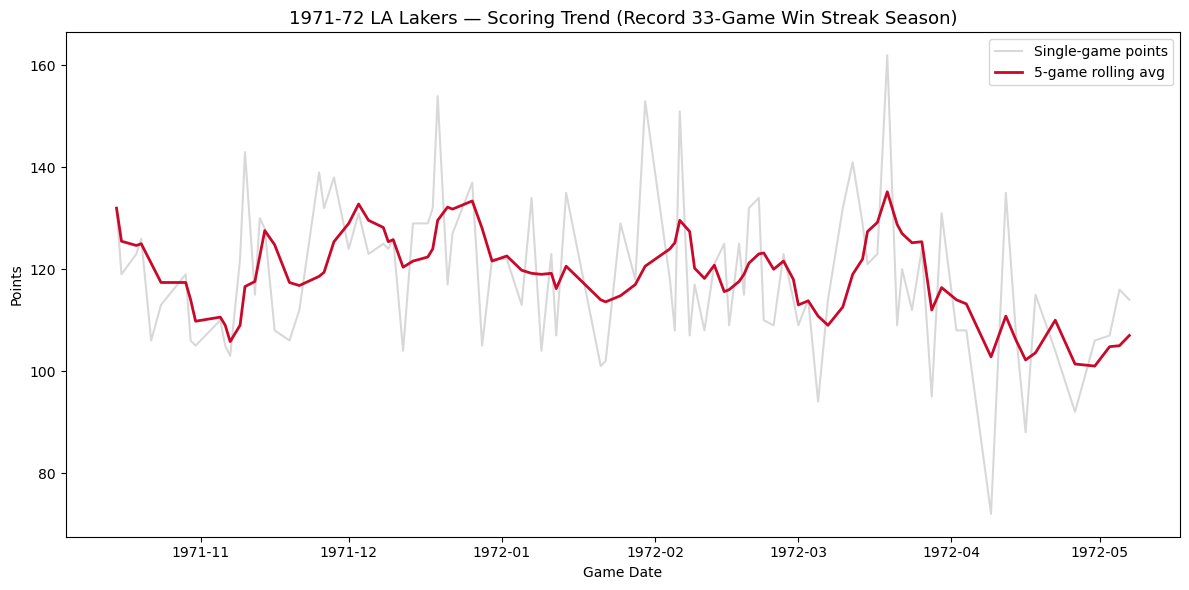

In [43]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df_q5['game_date'], df_q5['pts'], alpha=0.3, label='Single-game points', color='gray')
ax.plot(df_q5['game_date'], df_q5['rolling_5game_avg'], linewidth=2, label='5-game rolling avg', color='#C9082A')
ax.set_title('1971-72 LA Lakers — Scoring Trend (Record 33-Game Win Streak Season)', fontsize=13)
ax.set_xlabel('Game Date')
ax.set_ylabel('Points')
ax.legend()
plt.tight_layout()
plt.savefig('q5_lakers_rolling_avg.png', dpi=150)
plt.show()

## Q6 — Which franchises have the strongest home-court advantage?

Updated to `team_id` consolidation (same reasoning as Q1/Q3). Metric is
already a percentage (home win % minus away win %), not a raw count, so
no additional normalization was needed here — only the entity-level
grouping changed.

In [35]:
q6 = """
SELECT t.full_name AS franchise_name,
       ROUND(AVG(CASE WHEN location = 'home' THEN win END) * 100, 1) AS home_win_pct,
       ROUND(AVG(CASE WHEN location = 'away' THEN win END) * 100, 1) AS away_win_pct,
       ROUND(AVG(CASE WHEN location = 'home' THEN win END) * 100, 1) -
       ROUND(AVG(CASE WHEN location = 'away' THEN win END) * 100, 1) AS advantage_gap,
       COUNT(*) AS total_games
FROM (
    SELECT team_id_home AS team_id, 'home' AS location, CASE WHEN wl_home = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
    UNION ALL
    SELECT team_id_away AS team_id, 'away' AS location, CASE WHEN wl_away = 'W' THEN 1 ELSE 0 END AS win
    FROM game WHERE season_type = 'Regular Season'
) combined
JOIN team t ON combined.team_id = t.id
GROUP BY t.full_name
HAVING total_games >= 500
ORDER BY advantage_gap DESC
LIMIT 10;
"""
df_q6 = pd.read_sql(q6, conn)
print(df_q6)

           franchise_name  home_win_pct  away_win_pct  advantage_gap  \
0           Atlanta Hawks          64.8          34.9           29.9   
1          Denver Nuggets          64.1          34.7           29.4   
2        Sacramento Kings          59.8          31.7           28.1   
3               Utah Jazz          68.8          40.9           27.9   
4   Golden State Warriors          61.1          34.1           27.0   
5         Detroit Pistons          61.2          34.6           26.6   
6  Portland Trail Blazers          66.8          40.7           26.1   
7          Indiana Pacers          62.2          37.0           25.2   
8     Cleveland Cavaliers          59.2          34.7           24.5   
9          Boston Celtics          70.9          46.6           24.3   

   total_games  
0         5289  
1         3623  
2         5356  
3         3704  
4         5453  
5         5350  
6         3952  
7         3623  
8         3943  
9         5465  


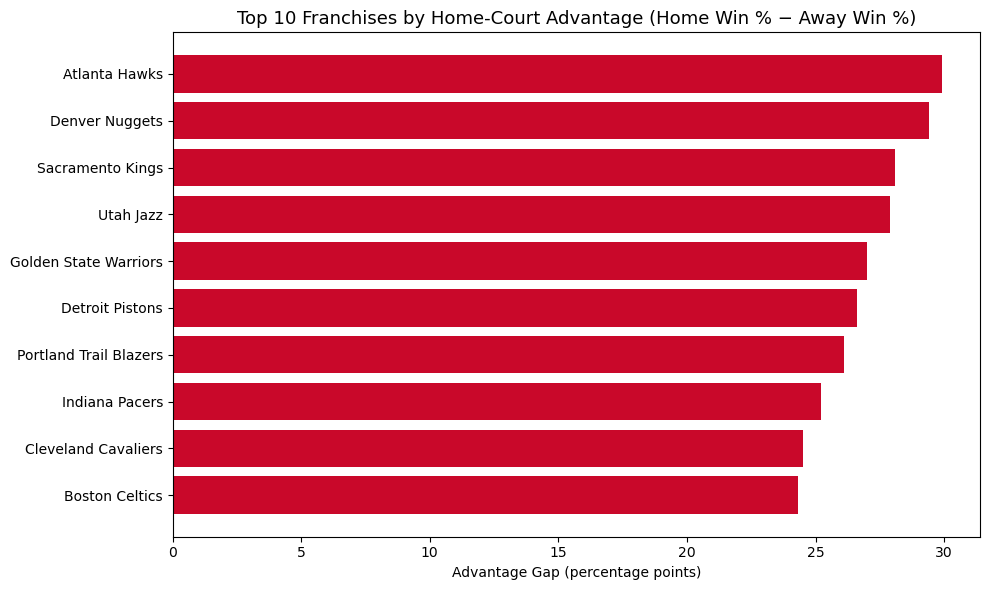

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_q6['franchise_name'][::-1], df_q6['advantage_gap'][::-1], color='#C9082A')
ax.set_title('Top 10 Franchises by Home-Court Advantage (Home Win % − Away Win %)', fontsize=13)
ax.set_xlabel('Advantage Gap (percentage points)')
plt.tight_layout()
plt.savefig('q6_home_advantage.png', dpi=150)
plt.show()

##
"Home-court advantage reflects historical differences in arena effects, travel, rule eras, and franchise history. It does not isolate the effect of home games alone."

## Q7 — Does draft position predict whether a player ever plays in the NBA?

Uses `LEFT JOIN` + `IS NULL` to find non-matches: drafted players who
never appear in `common_player_info` never made an NBA roster.

**Finding:** later-round picks are ~3x more likely than 1st-round picks to
never make an NBA roster (77.7% vs 26.6%).

**Limitation:** this dataset spans back to 1947, when the league had far
fewer roster spots overall (see Q2). Some of this gap likely reflects
structurally fewer roster spots in early eras, not purely draft-position
skill signal.

In [37]:
q7 = """
SELECT 
    CASE WHEN round_number = 1 THEN '1st Round' ELSE 'Later Rounds' END AS draft_round_group,
    COUNT(*) AS total_drafted,
    SUM(CASE WHEN cpi.person_id IS NULL THEN 1 ELSE 0 END) AS never_appeared_in_nba,
    ROUND(SUM(CASE WHEN cpi.person_id IS NULL THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS pct_never_played
FROM draft_history dh
LEFT JOIN common_player_info cpi ON dh.person_id = cpi.person_id
WHERE dh.draft_type = 'Draft'
GROUP BY draft_round_group;
"""
df_q7 = pd.read_sql(q7, conn)
print(df_q7)

  draft_round_group  total_drafted  never_appeared_in_nba  pct_never_played
0         1st Round           1625                    432              26.6
1      Later Rounds           6611                   5138              77.7


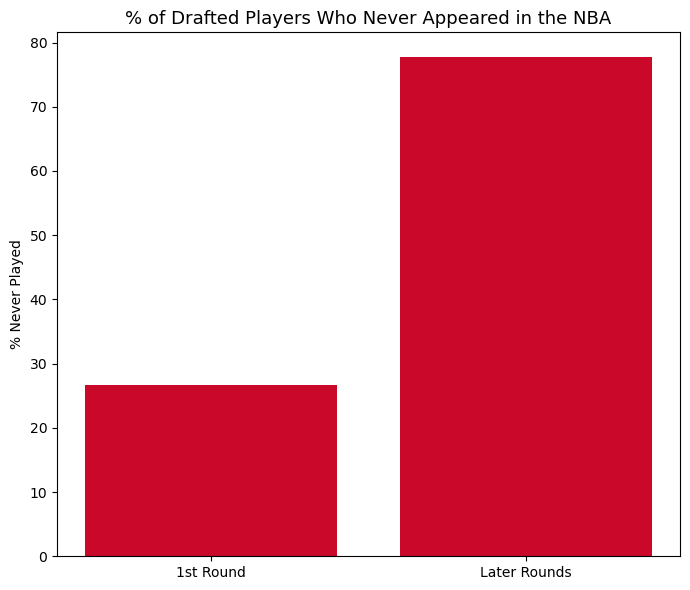

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.bar(df_q7['draft_round_group'], df_q7['pct_never_played'], color='#C9082A')
ax.set_title('% of Drafted Players Who Never Appeared in the NBA', fontsize=13)
ax.set_ylabel('% Never Played')
plt.tight_layout()
plt.savefig('q7_draft_outcomes.png', dpi=150)
plt.show()

##
Later-round picks are approximately 3x more likely to have no recorded NBA appearance compared with first-round selections.

## Export for Tableau

Query results exist only in this notebook session so far — exporting
each to CSV so Tableau has data sources to connect to, plus a small
summary-stats file for a dashboard "at a glance" tile.

In [46]:
df_q1_combined.to_csv('q1_franchise_wins.csv', index=False)
df_q2.to_csv('q2_scoring_by_decade.csv', index=False)
df_q3.to_csv('q3_franchise_scoring_avg.csv', index=False)
df_q4.to_csv('q4_win_streaks.csv', index=False)
df_q5.to_csv('q5_lakers_rolling_avg.csv', index=False)
df_q6.to_csv('q6_home_advantage.csv', index=False)
df_q7.to_csv('q7_draft_outcomes.csv', index=False)

print("All CSVs exported.")

All CSVs exported.


In [50]:
summary_stats = pd.DataFrame({
    'metric': [
        'Most Combined Wins (Regular Season + Playoffs)',
        'Peak Scoring Decade',
        'Longest Win Streak',
        'Strongest Home-Court Advantage',
        '1st Round Draft Success Rate',
        'Later Round Draft Success Rate'
    ],
    'value': [
        f"{df_q1_combined.iloc[0]['franchise_name']} ({int(df_q1_combined.iloc[0]['combined_wins'])} wins)",
        f"{int(df_q2.loc[df_q2['avg_total_points_per_game'].idxmax(), 'decade'])}s ({df_q2['avg_total_points_per_game'].max():.1f} pts/game)",
        f"{df_q4.iloc[0]['team_name']} ({int(df_q4.iloc[0]['streak_length'])} games, {df_q4.iloc[0]['streak_start'][:4]})",
        f"{df_q6.iloc[0]['franchise_name']} ({df_q6.iloc[0]['advantage_gap']} pt gap)",
        f"{100 - df_q7[df_q7['draft_round_group']=='1st Round']['pct_never_played'].values[0]:.1f}%",
        f"{100 - df_q7[df_q7['draft_round_group']=='Later Rounds']['pct_never_played'].values[0]:.1f}%"
    ]
})
summary_stats.to_csv('summary_stats.csv', index=False)
print(summary_stats)

# Separate comparison file: Lakers vs Celtics, since this is a near-tie
# (29 wins apart across ~80 years) worth showing side-by-side in
# Tableau, not collapsed into a single "#1" stat that hides the story
wins_comparison = df_q1_combined.head(2)[['franchise_name', 'regular_season_wins', 'playoff_wins', 'combined_wins']].copy()
wins_comparison.to_csv('q1_top2_comparison.csv', index=False)
print("\nTop 2 comparison (for Tableau callout):")
print(wins_comparison)

                                           metric  \
0  Most Combined Wins (Regular Season + Playoffs)   
1                             Peak Scoring Decade   
2                              Longest Win Streak   
3                  Strongest Home-Court Advantage   
4                    1st Round Draft Success Rate   
5                  Later Round Draft Success Rate   

                                 value  
0       Los Angeles Lakers (3595 wins)  
1               1960s (227.9 pts/game)  
2  Los Angeles Lakers (33 games, 1971)  
3          Atlanta Hawks (29.9 pt gap)  
4                                73.4%  
5                                22.3%  

Top 2 comparison (for Tableau callout):
       franchise_name  regular_season_wins  playoff_wins  combined_wins
0  Los Angeles Lakers                 3193           402           3595
1      Boston Celtics                 3210           356           3566


## Close Connection

In [ ]:
## Close Connection